In [1]:
from astropy.table import Table 
import numpy as np

# load data onto an astropy table
jades_path = '/home/caltech-msanche3/data/JADES_south_fits_data.fits'
jades_data = Table.read(jades_path, hdu='CIRC_BSUB',format='fits')
# change units of flux from nJy to microJy so eazy fits correctly
print(jades_data.colnames)
for col in jades_data.colnames:
    if '_CIRC1' in col or '_ei' in col:
        jades_data[col] = jades_data[col] * 0.001
redshift = Table.read(jades_path, hdu='PHOTOZ_KRON',format='fits')


['ID', 'RA', 'DEC', 'F070W_CIRC0', 'F070W_CIRC0_bkg', 'F070W_CIRC0_e', 'F070W_CIRC0_ei', 'F070W_CIRC1', 'F070W_CIRC1_bkg', 'F070W_CIRC1_e', 'F070W_CIRC1_ei', 'F070W_CIRC2', 'F070W_CIRC2_bkg', 'F070W_CIRC2_e', 'F070W_CIRC2_ei', 'F070W_CIRC3', 'F070W_CIRC3_bkg', 'F070W_CIRC3_e', 'F070W_CIRC3_ei', 'F070W_CIRC4', 'F070W_CIRC4_bkg', 'F070W_CIRC4_e', 'F070W_CIRC4_ei', 'F070W_CIRC5', 'F070W_CIRC5_bkg', 'F070W_CIRC5_e', 'F070W_CIRC5_ei', 'F070W_CIRC6', 'F070W_CIRC6_bkg', 'F070W_CIRC6_e', 'F070W_CIRC6_ei', 'F090W_CIRC0', 'F090W_CIRC0_bkg', 'F090W_CIRC0_e', 'F090W_CIRC0_ei', 'F090W_CIRC1', 'F090W_CIRC1_bkg', 'F090W_CIRC1_e', 'F090W_CIRC1_ei', 'F090W_CIRC2', 'F090W_CIRC2_bkg', 'F090W_CIRC2_e', 'F090W_CIRC2_ei', 'F090W_CIRC3', 'F090W_CIRC3_bkg', 'F090W_CIRC3_e', 'F090W_CIRC3_ei', 'F090W_CIRC4', 'F090W_CIRC4_bkg', 'F090W_CIRC4_e', 'F090W_CIRC4_ei', 'F090W_CIRC5', 'F090W_CIRC5_bkg', 'F090W_CIRC5_e', 'F090W_CIRC5_ei', 'F090W_CIRC6', 'F090W_CIRC6_bkg', 'F090W_CIRC6_e', 'F090W_CIRC6_ei', 'F105W_CIRC0',

In [2]:
# ID 12326 is likely not correct and I will be ommiting it for the time being
# there are outliers in this list
# total objs: 13
ids = [13405,14376,27503,96216,107324,127219,131688,131971,132845,135819,165595,169896,265801,318988]
zspec = [7.95,7.96,8.19,12.48,9.68,6.63,6.33,6.32,6.09,7.04,8.58,6.16,9.43,6.04]
jades_zphot = [8.35,7.50,8.55,12.46,10.29,6.51,6.29,6.60,6.09,7.05,8.98,6.32,9.9,6.54]
mask = []
for i in range(len(jades_data)):
    if jades_data[i]['ID'] in ids:
        mask.append(True)
    else:
        mask.append(False)

new_jades_data = jades_data[mask]
new_jades_data.add_column(zspec,name='ZSPEC',index=2)
print(new_jades_data)

  ID       RA    ZSPEC ... F850LP_CIRC6_e   F850LP_CIRC6_ei   
          deg          ...      nJy               nJy         
------ --------- ----- ... -------------- --------------------
 13405 53.103912  7.95 ...       18.65322    0.018650146484375
 14376 53.076694  7.96 ...      22.322878 0.022320674896240233
 27503 53.075806  8.19 ...      19.595543 0.019591638565063477
 96216 53.166344 12.48 ...      5.0580993  0.00505741548538208
107324 53.167355  9.68 ...      5.4513164 0.005449738025665283
127219  53.16905  6.63 ...       5.488443 0.005488416194915771
131688  53.13492  6.33 ...      32.210308  0.03219993209838867
131971   53.1666  6.32 ...       5.235929 0.005234539985656738
132845  53.15952  6.09 ...      10.175247 0.010170273780822754
135819 53.134228  7.04 ...      16.277985 0.016259729385375978
165595   53.0583  8.58 ...       25.81777 0.025802650451660157
169896 53.091164  6.16 ...      19.488157   0.0194802360534668
265801  53.11243  9.43 ...      18.213316 0.01821312332

In [5]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = new_jades_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 5
params['Z_MAX'] = 15
params['IGM_SCALE_TAU'] = 1.0
params['FIX_ZSPEC'] = True
#params['RENORM_TEMPLATES'] = False
params['PRIOR_ABZP'] = 23.90

# 2. Tell it what templates to use to fit the light
params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"

# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'JADES_south_45k_fit_circ'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file_circ.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 14
F070W_CIRC1 F070W_CIRC1_ei (362): jwst_nircam_f070w
F090W_CIRC1 F090W_CIRC1_ei (363): jwst_nircam_f090w
F105W_CIRC1 F105W_CIRC1_ei (202): hst/wfc3/IR/f105w.dat
F115W_CIRC1 F115W_CIRC1_ei (364): jwst_nircam_f115w
F125W_CIRC1 F125W_CIRC1_ei (203): hst/wfc3/IR/f125w.dat
F140W_CIRC1 F140W_CIRC1_ei (204): hst/wfc3/IR/f140w.dat
F150W_CIRC1 F150W_CIRC1_ei (365): jwst_nircam_f150w
F160W_CIRC1 F160W_CIRC1_ei (205): hst/wfc3/IR/f160w.dat
F162M_CIRC1 F162M_CIRC1_ei (369): jwst_nircam_f162m
F182M_CIRC1 F182M_CIRC1_ei (370): jwst_nircam_f182m
F200W_CIRC1 F200W_CIRC1_ei (366): jwst_nircam_f200w
F210M_CIRC1 F210M_CIRC1_ei (371): jwst_nircam_f210m
F250M_CIRC1 F250M_CIRC1_ei (379): jwst_nircam_f250m
F277W_CIRC1 F277W_CIRC1_ei (375): jwst_nircam_f277w

100%|██████████| 6/6 [00:19<00:00,  3.18s/it]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 21.307 s


99it [00:00, 25124.71it/s]

Fitting program initialized successfully!


In [6]:
#ez.fit_catalog(ez.idx[mask],n_proc=16)

ez.cat['z_spec'] = new_jades_data['ZSPEC']
ez.fit_catalog(ez.idx,n_proc=16)

100%|██████████| 99/99 [00:00<00:00, 4688.33it/s]

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=14)
Fit 0.2 s (n_proc=16, NOBJ=14)


In [7]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 0.0 s (n_proc=1,  NOBJ=14)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 14/14 [00:00<00:00, 244.58it/s]

CALLED 45K Templates


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3959539/4105205035.py:56: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}",


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


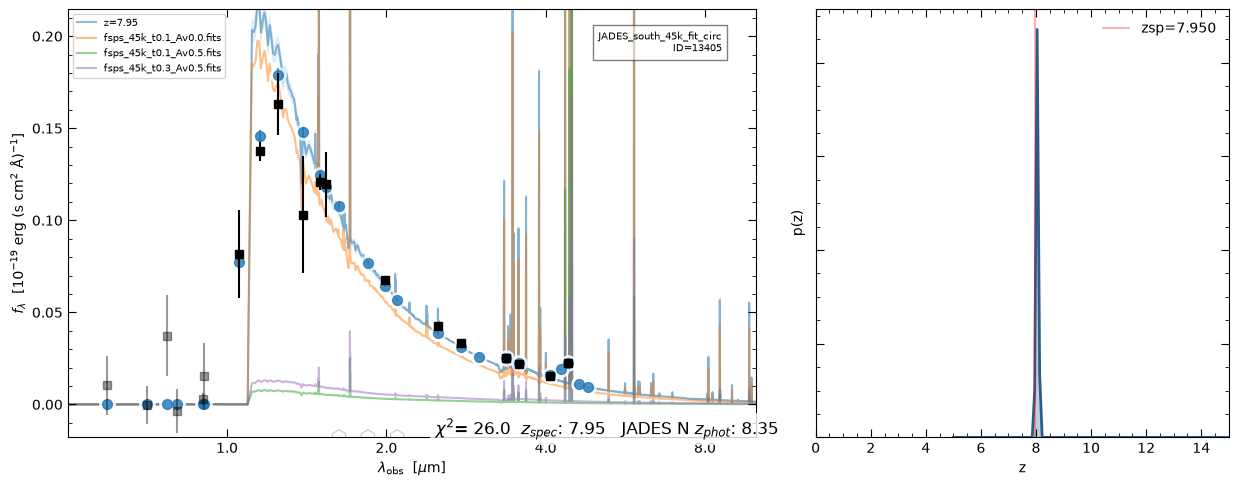

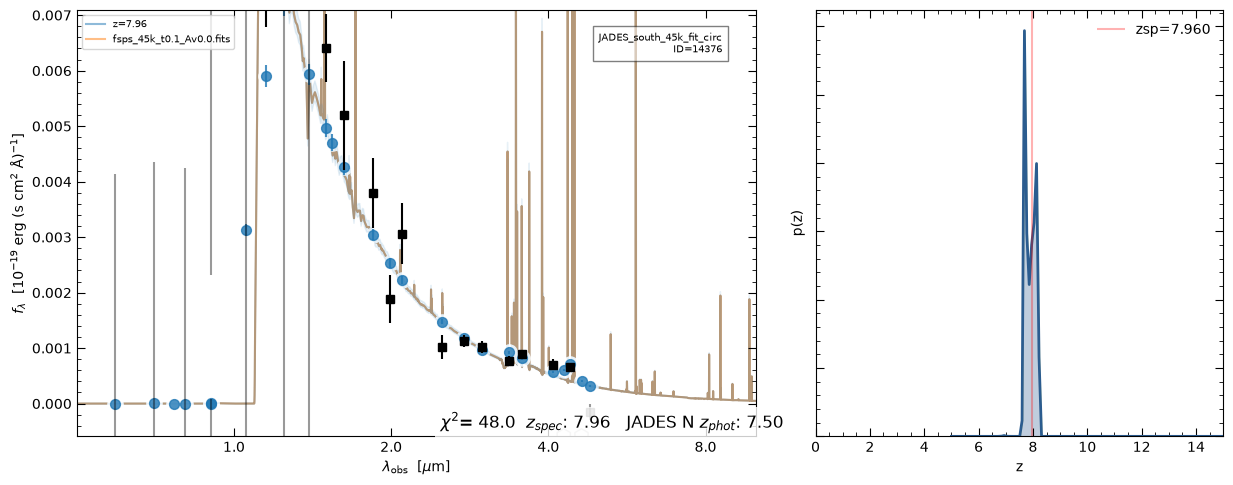

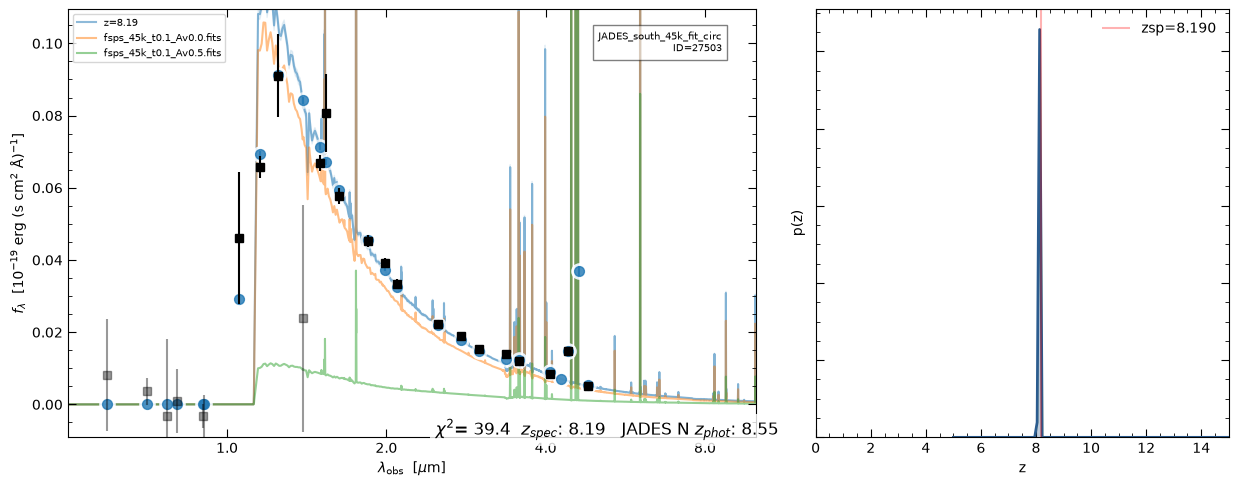

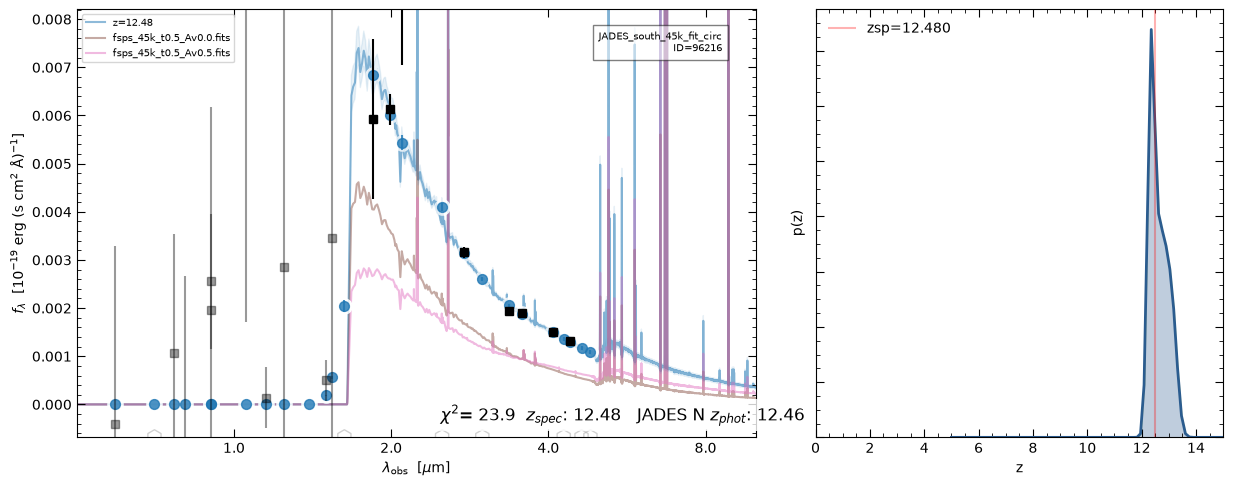

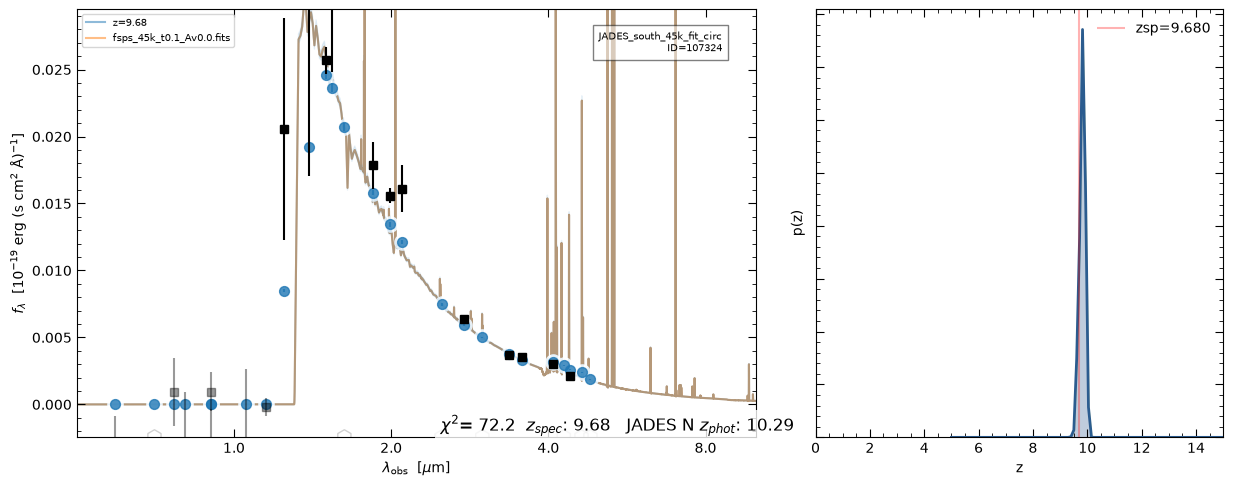

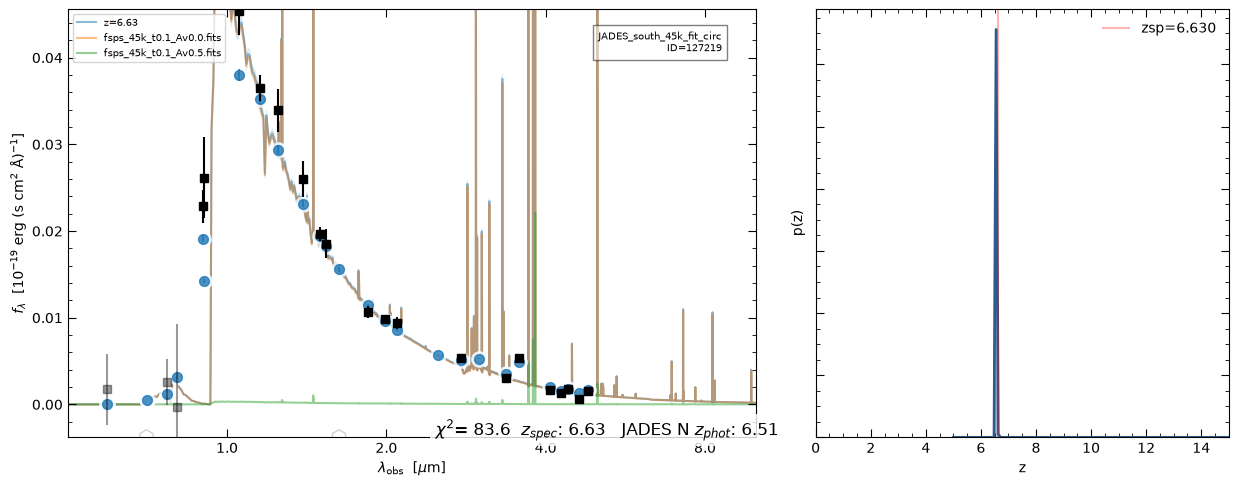

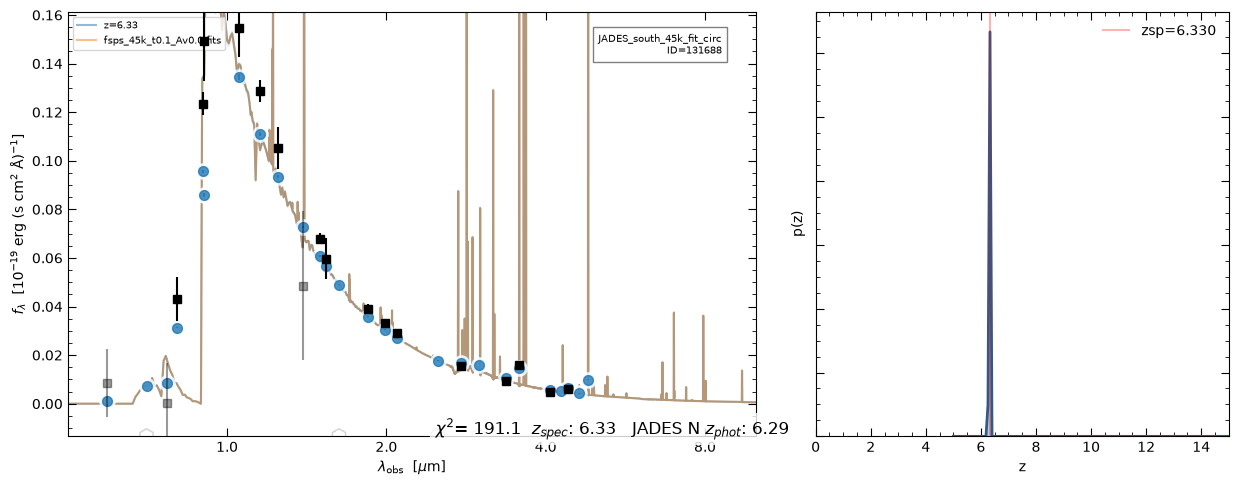

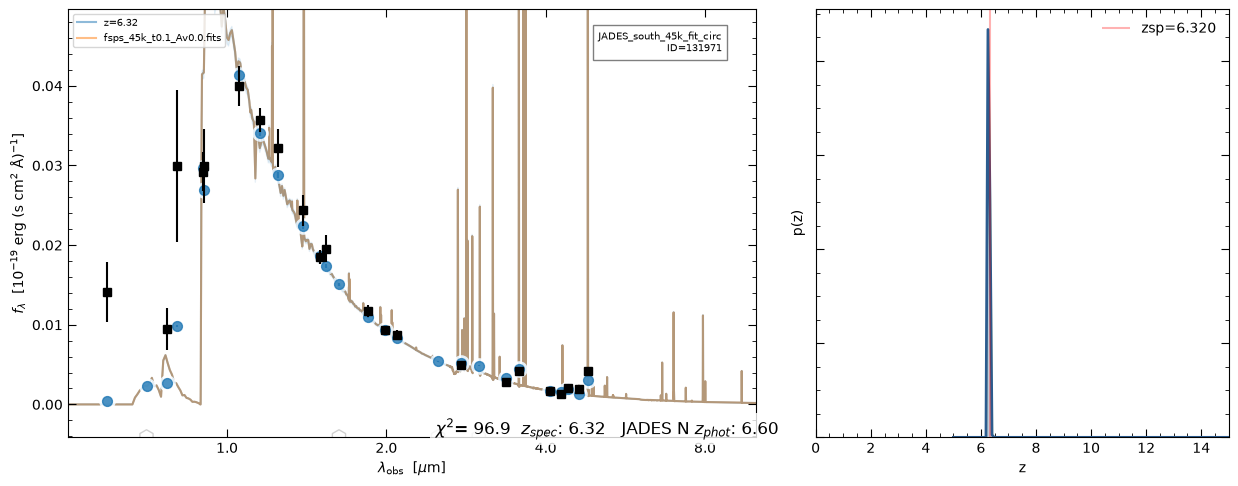

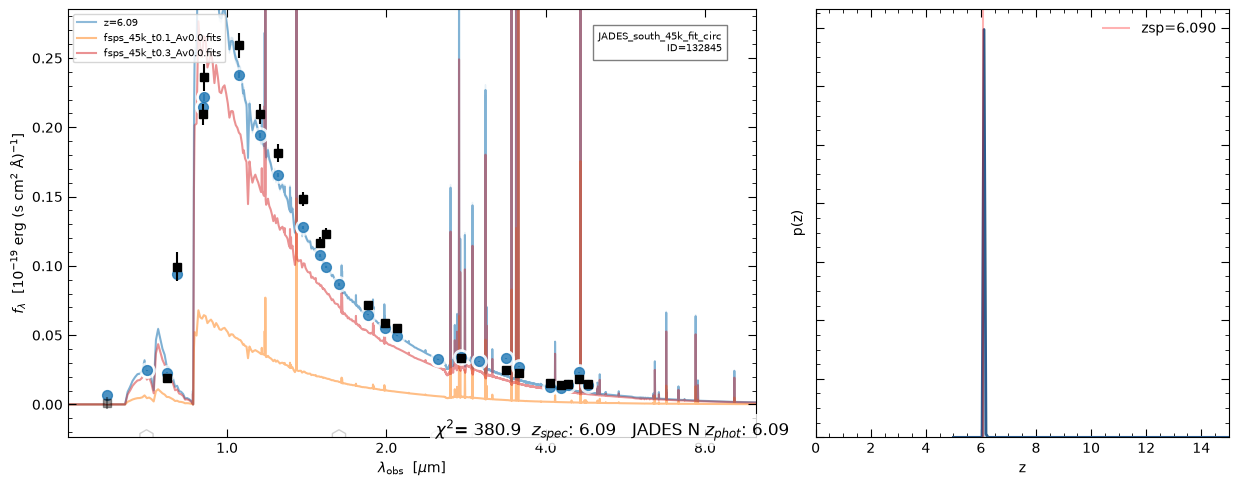

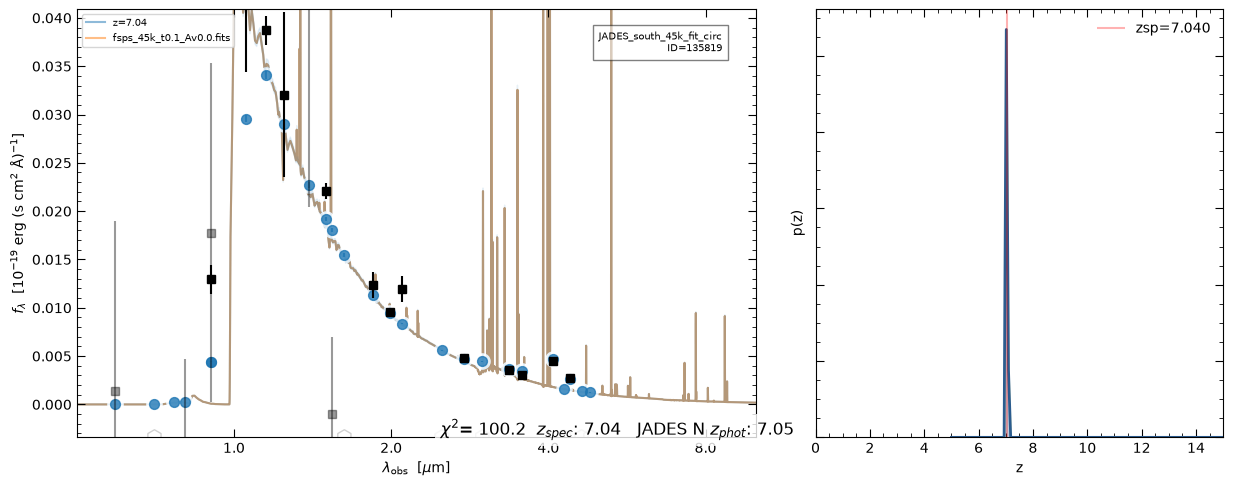

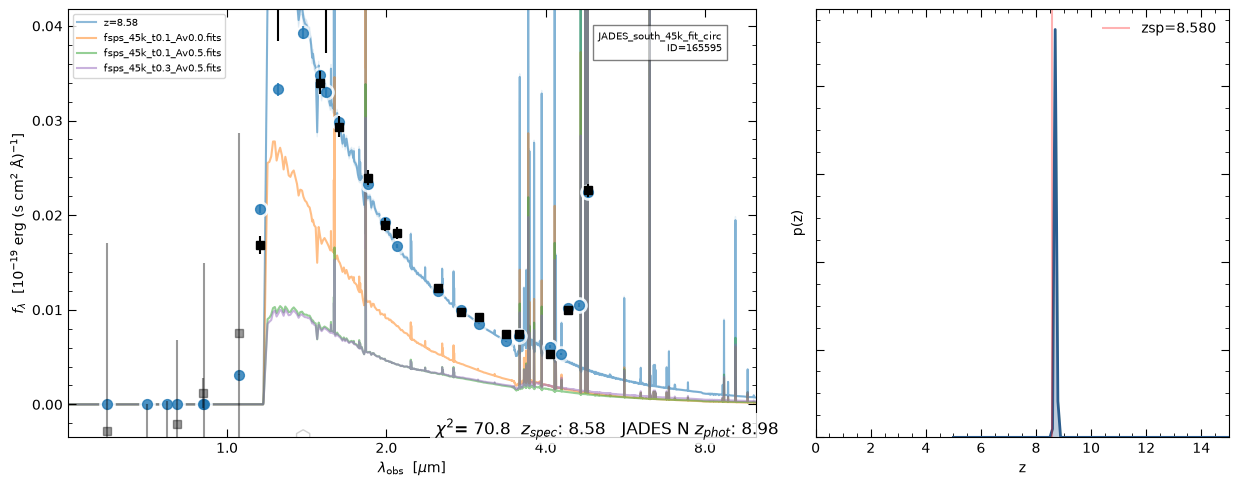

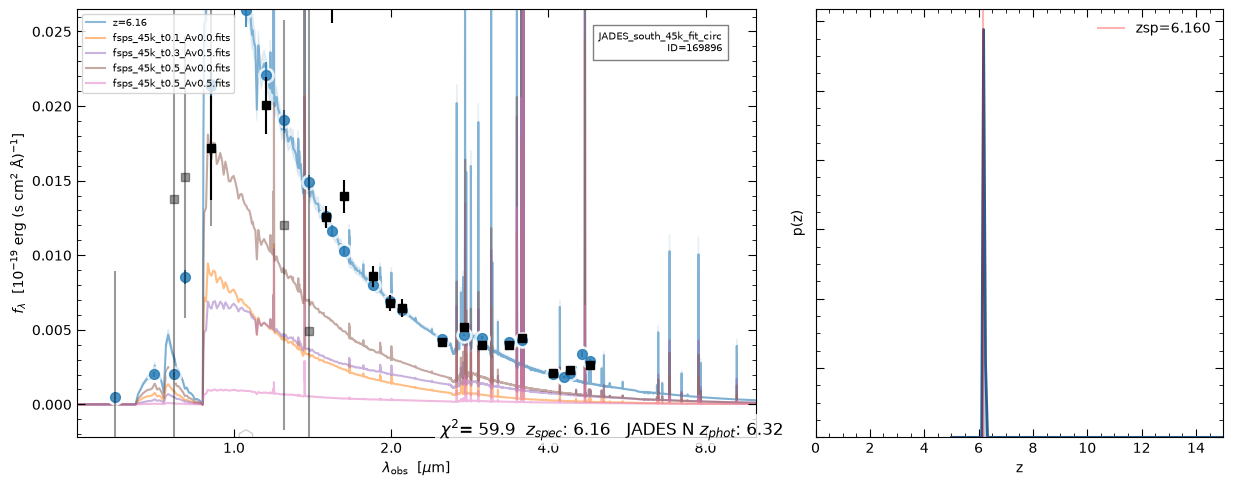

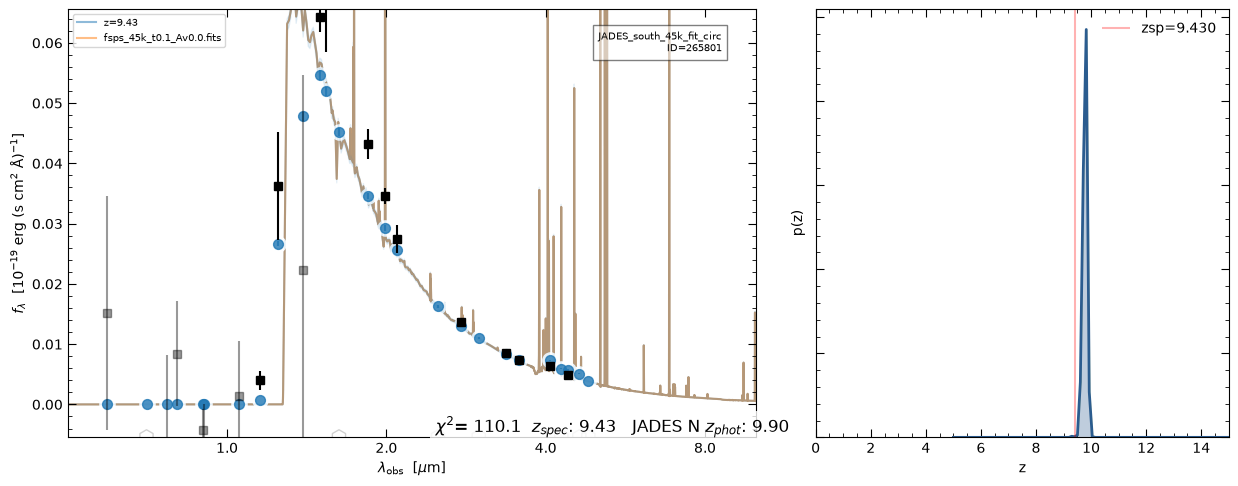

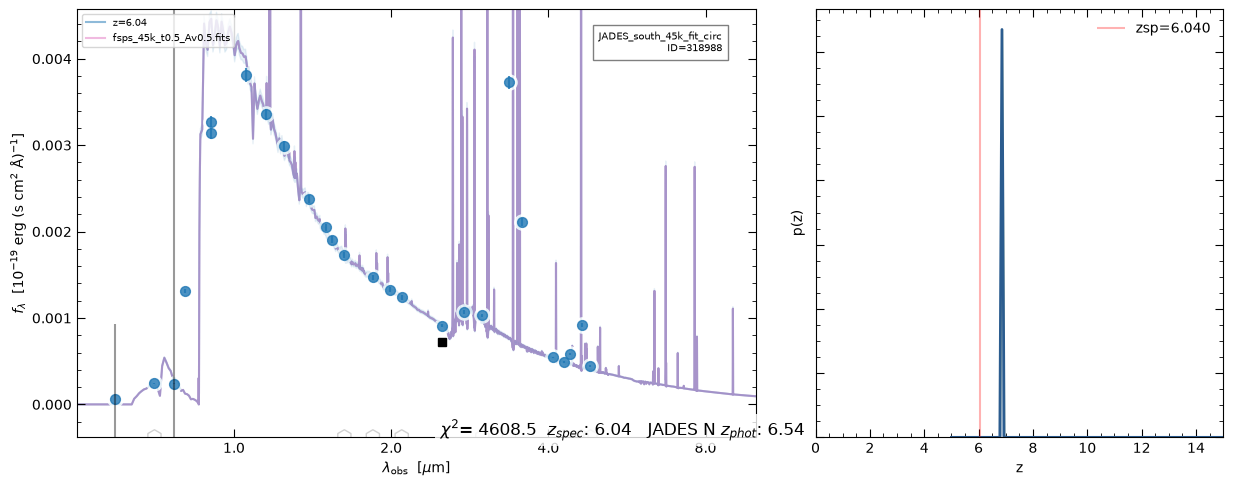

In [10]:
from matplotlib.ticker import AutoMinorLocator

output_path = '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/45K Fitting/JADES_south_45k_fit_circ.zout.fits'
output_data = Table.read(output_path)

ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 10], show_components=True,
                            logpz=False, zr=[0,15])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    #fig.axes[0].set_ylim(0, 0.52)

    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 

275.46251340966955
3.4845936108250086
100.02389428545307
2.083972217333073
4.865533375462776
17.05349526714639
314.26641268768105
21.19951956266621
149.72161095296283
15.39952015111518
56.70151264912978
2.593488645917403
172.47090690467456
395.2678496089645


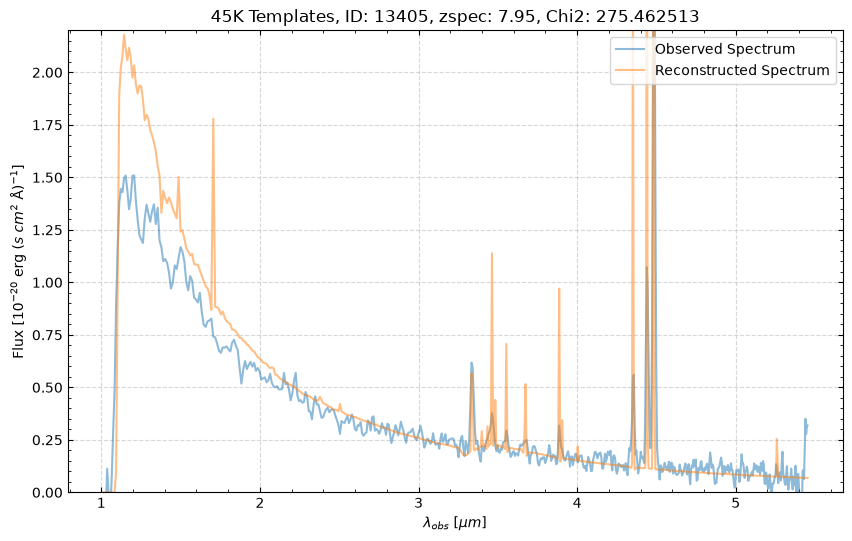

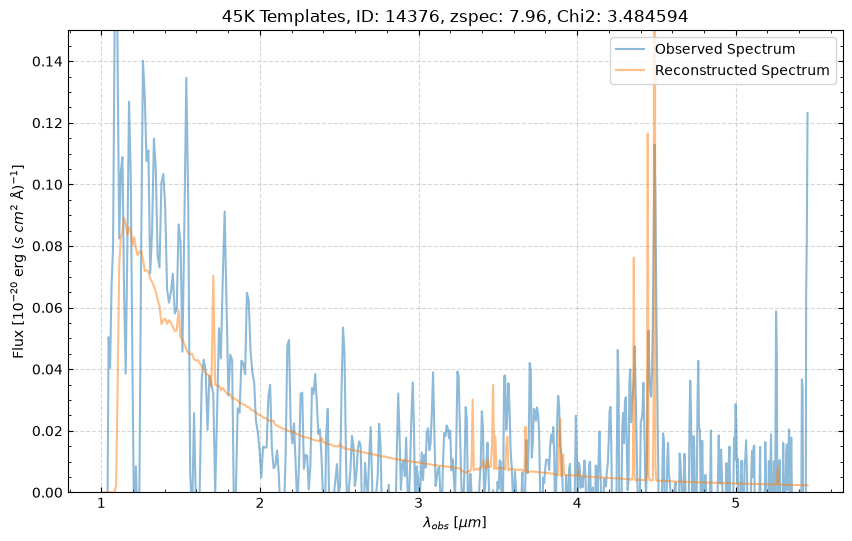

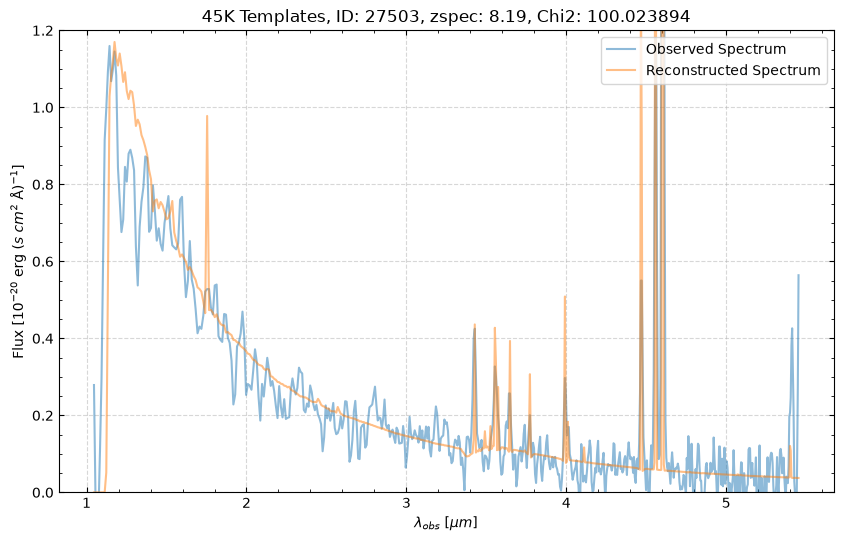

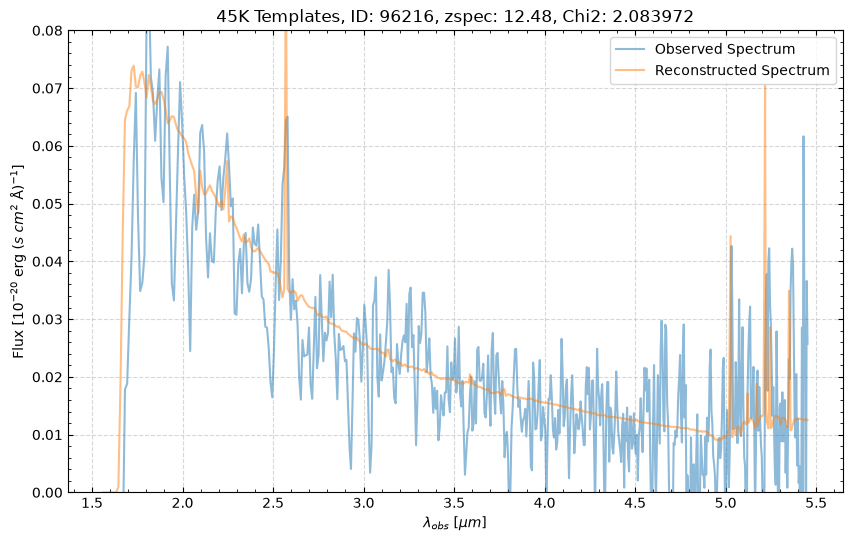

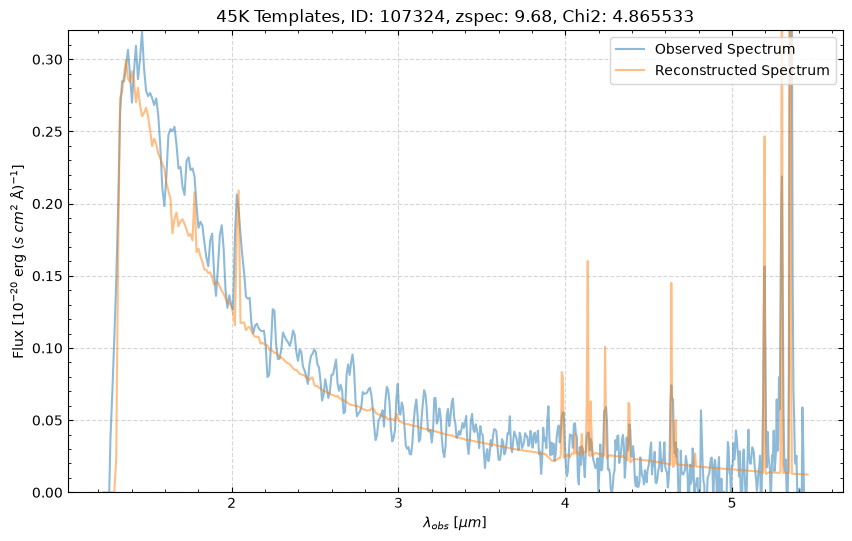

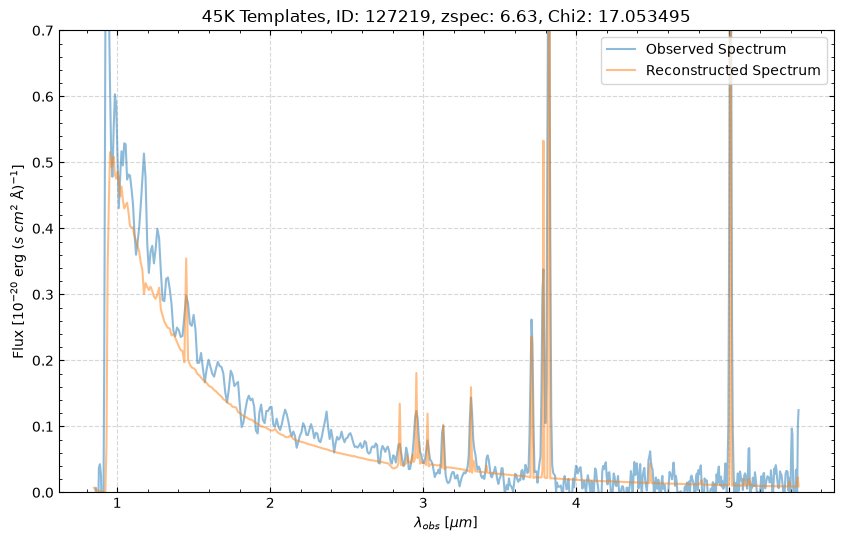

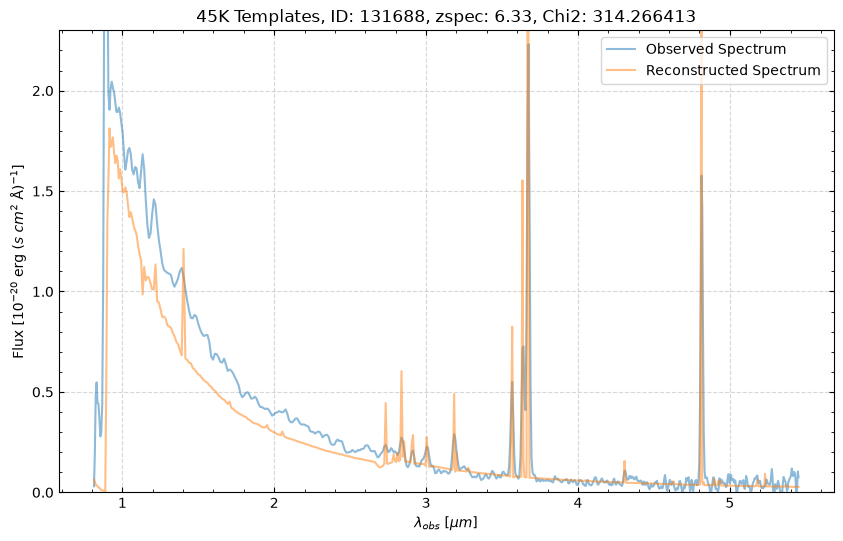

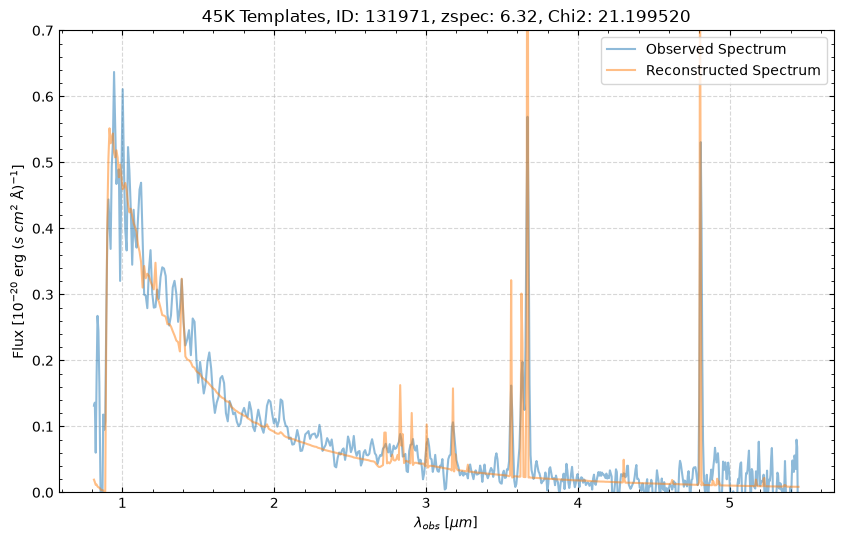

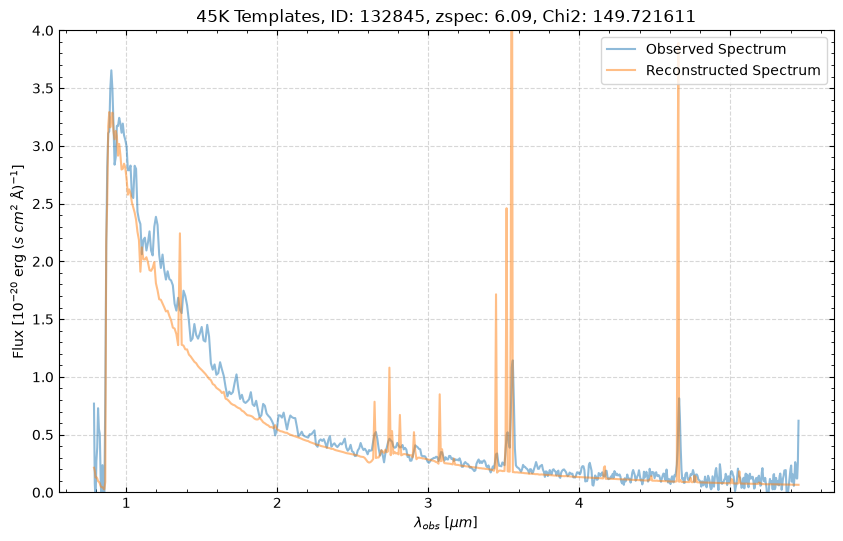

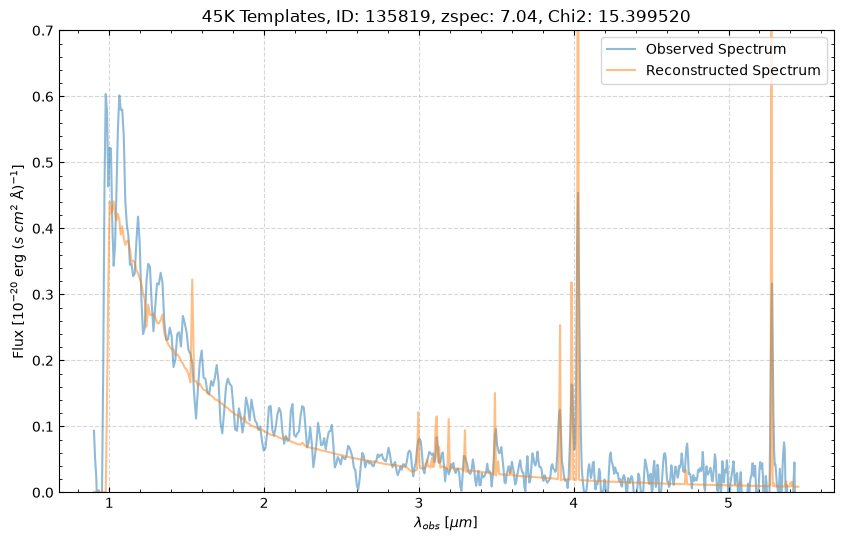

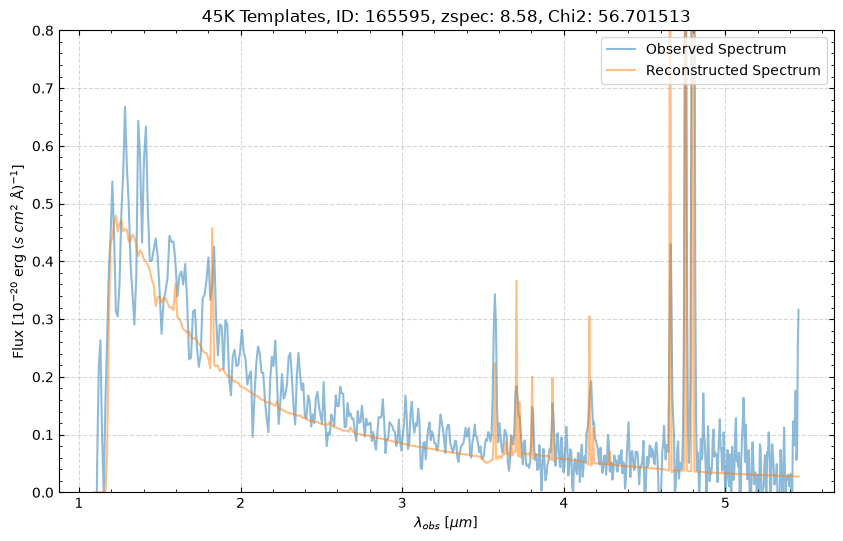

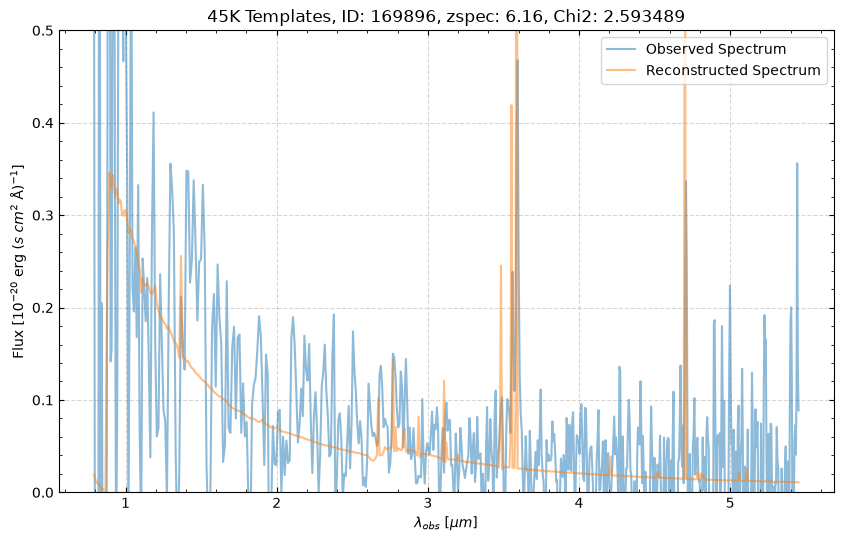

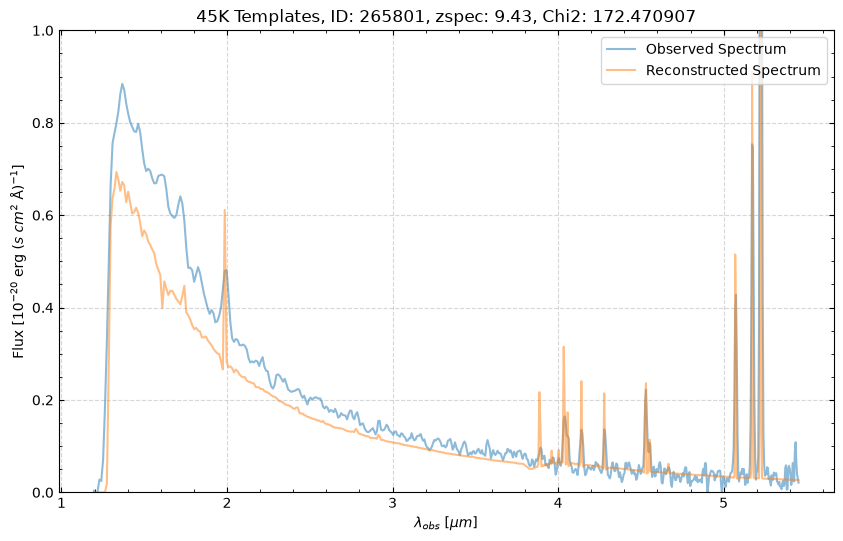

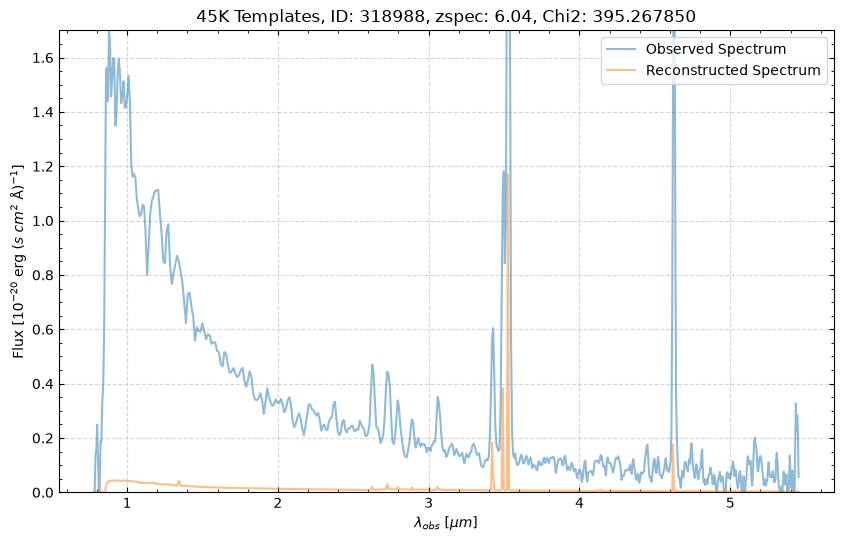

In [23]:
from spectres import spectres
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

paths = [
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_13405.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_14376.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_27503.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_96216.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_107324.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_127219.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_131688.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_131971.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_132845.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_135819.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_165595.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_169896.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_265801.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_318988.fits'
]

ylims = [2.2,.15,1.2,.08,.32,.7,2.3,.7,4,.7,.8,.5,1,1.7]
nrmsers = []
for i in range(len(ids)):

    # generate model data
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0,renorm_t=False)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model=sed_data['templf']*10 # multiply times ten to make to units of 10^-20 erg/s/cm2/AA

    # generate observed data
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    #flux_obs = data['FLUX']
    flux_obs = data['FLUX']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA
    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA

    # interpolate model to fit the wavelength array of the observed data
    flux_model_interp = spectres(
        wave_obs,                # Target wavelength
        wave_model,              # model wavelength grid
        flux_model,             #  model flux
        fill=np.nan,             # Fill value for out-of-bounds wavelengths
        verbose=False
    )

    # mask any value less than the lyman alpha drop off because it is different physics there
    mask = (wave_obs > (.1216*(1+zspec[i]))-.08)

    # calculate the reduced chi^2
    res = ((flux_obs[mask]-flux_model_interp[mask])/err_obs[mask]) ** 2
    chi2 = np.sum(res)/len(flux_obs[mask])
    print(chi2)

    fig,ax = plt.subplots(figsize=(10,6))

    ax.plot(wave_obs[mask],flux_obs[mask],alpha=.5)
    ax.plot(wave_obs[mask],flux_model_interp[mask],alpha=.5)

    ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')
    ax.set_ylabel(r'Flux [$10^{-20}$ erg $(s \text{ } cm^2 \text{ } \mathrm{\AA})^{-1}]$')

    ax.set_ylim(0,ylims[i])
    ax.set_title(f'45K Templates, ID: {ids[i]}, zspec: {zspec[i]}, Chi2: {chi2:1f}')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
    ax.legend(['Observed Spectrum','Reconstructed Spectrum'],loc='upper right')
    ax.minorticks_on()

13405
14376
27503
96216
107324
127219
131688
131971
132845
135819
165595
169896
265801
318988


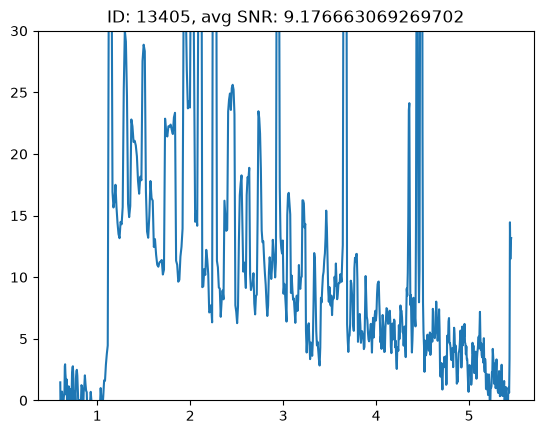

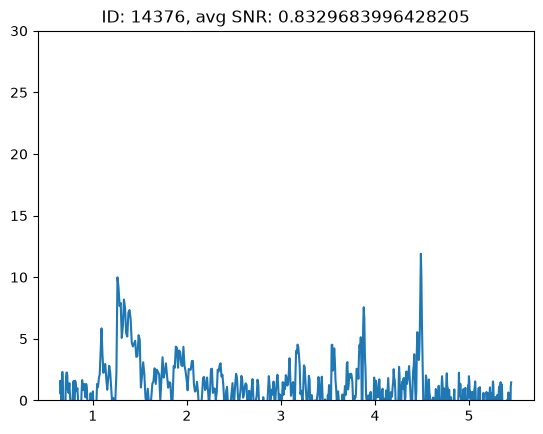

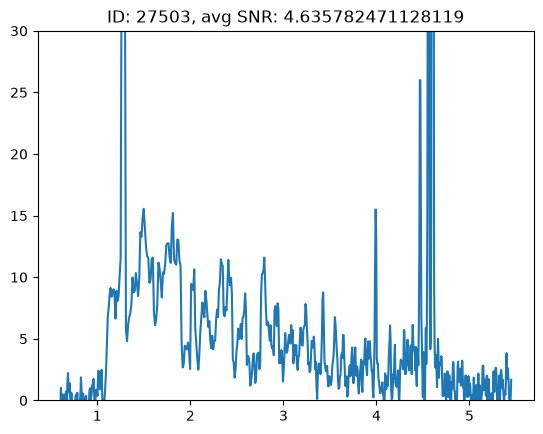

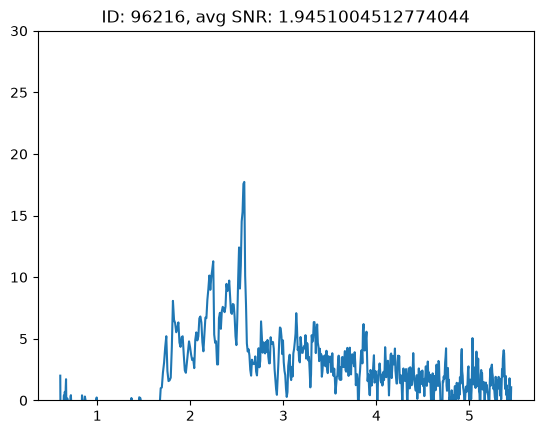

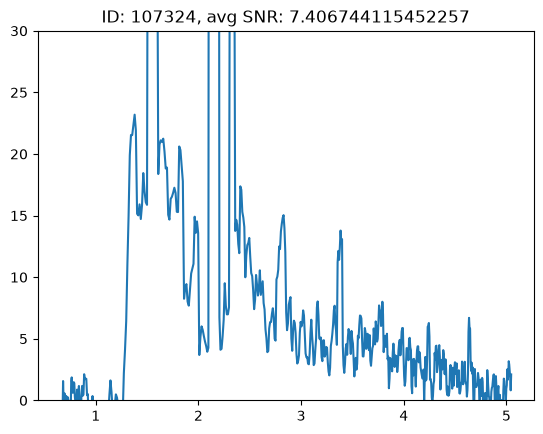

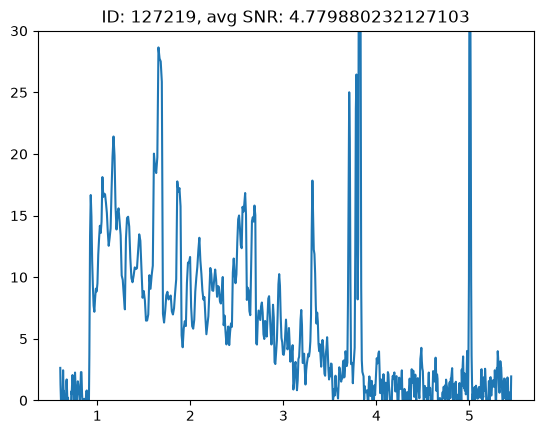

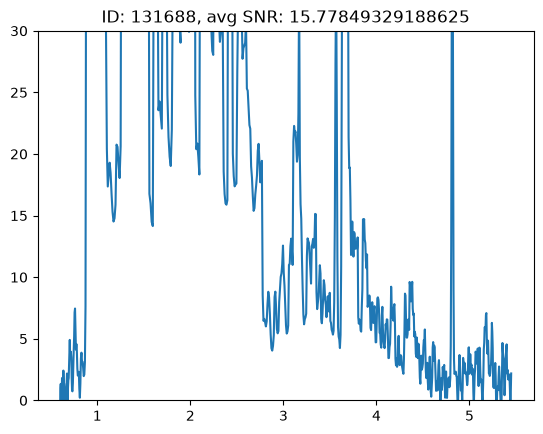

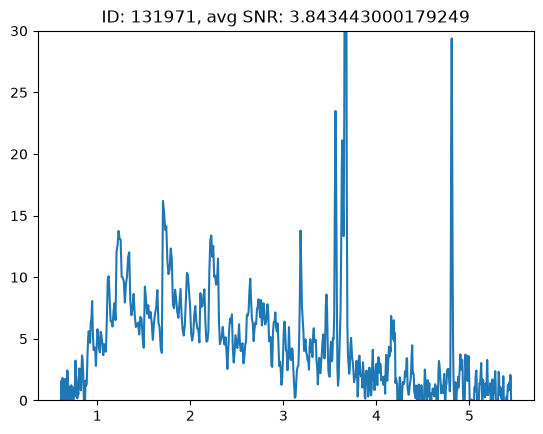

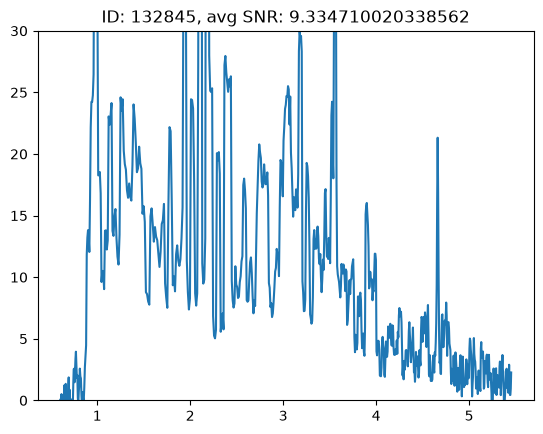

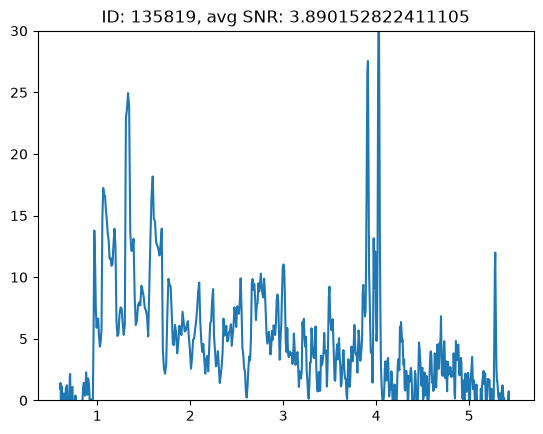

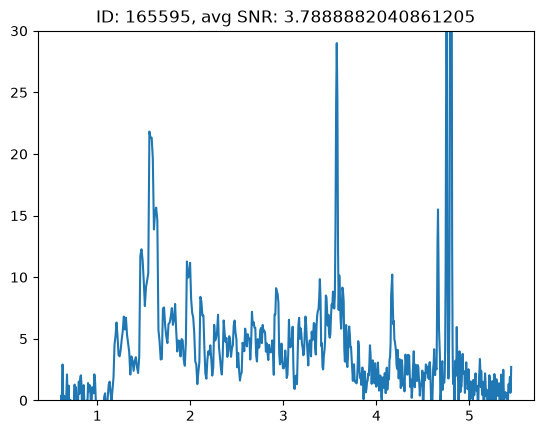

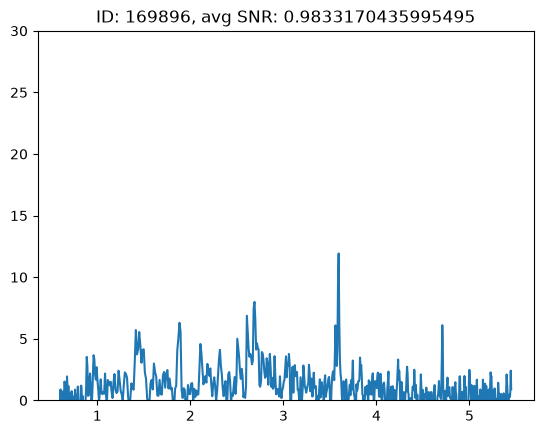

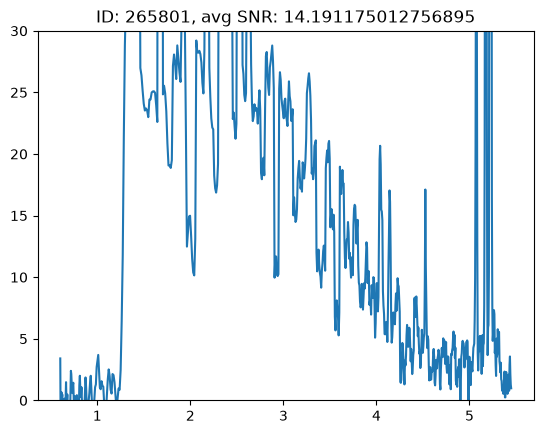

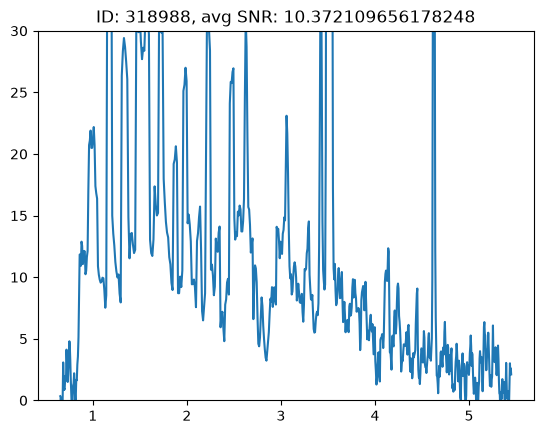

In [15]:
for i in range(len(ids)):
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model = sed_data['templf']*1e-19 # Best-fit template flux density
    print(ids[i])
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    flux_obs = data['FLUX']
    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']

    fig,ax = plt.subplots()
    ax.plot(wave_obs,flux_obs/err_obs)
    ax.set_title(f'ID: {ids[i]}, avg SNR: {np.mean(flux_obs/err_obs)}')
    ax.set_ylim(0,30)